In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PREFIX = "inertial-6286.188861:"

buff = []
with open("accel.csv", "r") as file:
# with open("CB_ARW.csv", "r") as file:
    data = False
    for line in file:
        
        if line == "DATA_START\n":
            data = True
            continue
        
        if data == True:
            line = line.rstrip()
            values = line.split(",")
            buff.append(values)

header = [b.lstrip(PREFIX) for b in buff[0]]

buff = np.array(buff)

df = pd.DataFrame(data=buff[1:], columns=header)

# Conversion de tipo de datos de df (string a numerico)
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# print(df)

fs = 100
dt = 1 / fs

In [26]:
def mean(df, col):
    return np.mean(pd.to_numeric(df[col], errors="coerce"))

def variance(df, col):    
    return np.var(pd.to_numeric(df[col], errors="coerce"))

def standard_deviation(df, col):  
    return np.std(pd.to_numeric(df[col], errors="coerce"))
    
# for column in df.columns[1:]:
#     print(column)
#     mean(df=df, col=column)
#     variance(df=df, col=column)
#     standard_deviation(df=df, col=column)

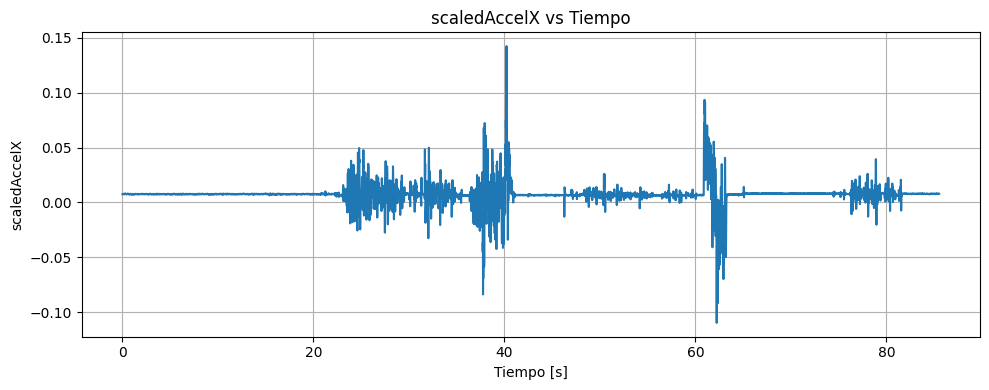

scaledAccelX  u: 0.007439115671773871  o2: 0.00010102175799526937  o: 0.010050958063551423


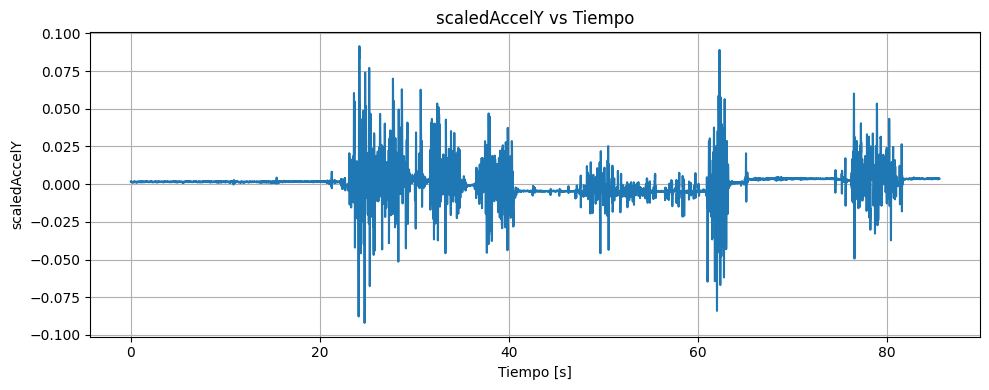

scaledAccelY  u: 0.000860236848353127  o2: 0.00011092442201041907  o: 0.010532066369446171


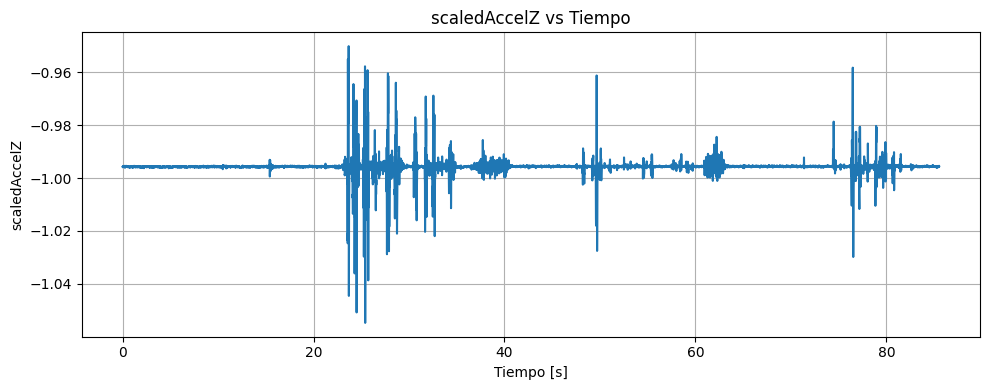

scaledAccelZ  u: -0.9956417328806327  o2: 1.246592380188406e-05  o: 0.00353071151496183


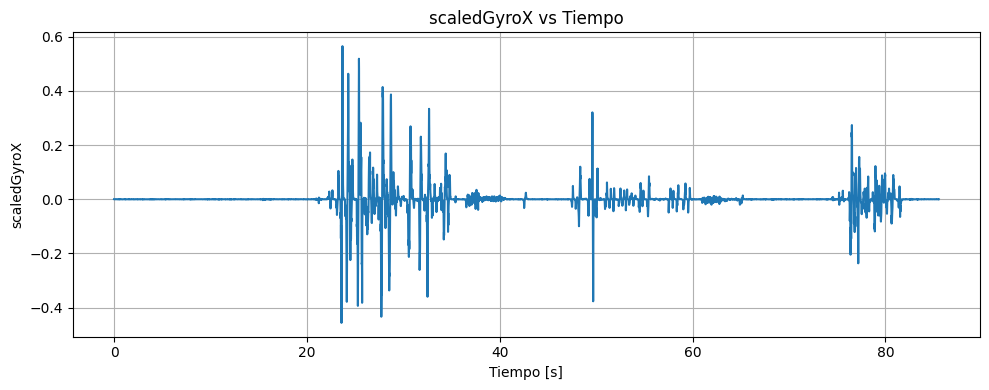

scaledGyroX  u: 4.3781964534203605e-05  o2: 0.002031034706348217  o: 0.045067002411389834


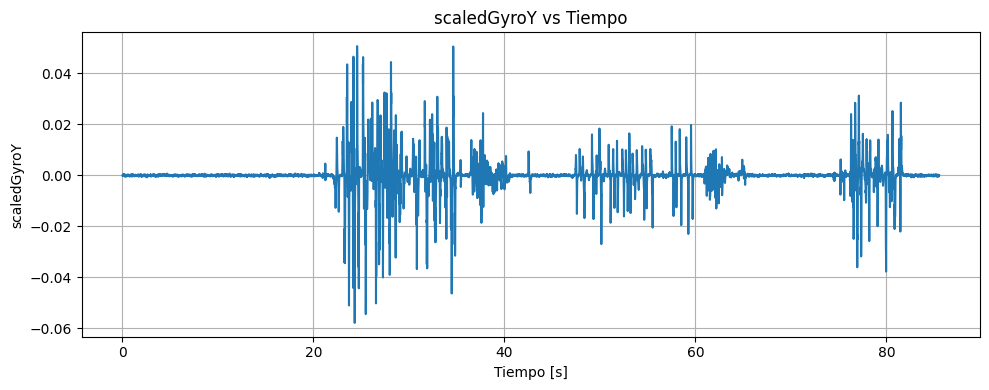

scaledGyroY  u: -8.26865266571699e-05  o2: 2.953415158565337e-05  o: 0.005434533244507146


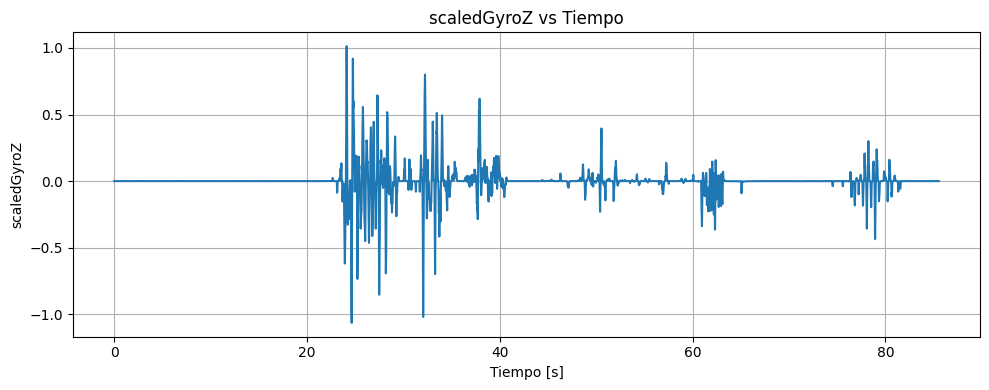

scaledGyroZ  u: -0.0007429326407944792  o2: 0.010452865219616534  o: 0.10223925478805357
{'scaledAccelX': np.float64(0.007439115671773871), 'scaledAccelY': np.float64(0.000860236848353127), 'scaledAccelZ': np.float64(-0.9956417328806327), 'scaledGyroX': np.float64(4.3781964534203605e-05), 'scaledGyroY': np.float64(-8.26865266571699e-05), 'scaledGyroZ': np.float64(-0.0007429326407944792)}


In [27]:
# sigma = 0.01 # desviación estandar

# rudio_gyro = np.random.normal(loc=0, scale=sigma, size=n)

# # plt.plot(np.arange(n) * dt, rudio_gyro)
# # plt.xlabel("Tiempo [s]")
# # plt.ylabel("Ruido del giroscopio [deg/s]")
# # plt.title("Ruido blanco en velocidad angular")
# # plt.grid()
# # plt.show()

# print(df.columns[3])
biases = {}

def plot_data_vs_time(df, col):
    df = df.copy()

    # Convertir Time a numérico
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

    # Eliminar filas donde Time no pudo convertirse
    # df = df.dropna(subset=["Time"])

    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col)
    plt.title(f"{col} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
        
# plot_data_vs_time(df=df, col="scaledAccelY")

for column in df.columns[1:]:
    plot_data_vs_time(df=df, col=column)
    print(column, " u:", mean(df,column), " o2:", variance(df,column)," o:", standard_deviation(df,column))
    biases[column] = mean(df,column)

print(biases)

# print(biases[df.columns[1]])

In [28]:
var = {}
std = {}

CALIBRATION_TIME = 30
CALIBRATION_LINES = int(CALIBRATION_TIME / dt)

for column in df.columns[1:7]:
    # print(df[column].iloc[:CALIBRATION_LINES])
    initialize_data = df[column].iloc[:CALIBRATION_LINES]
    biases[column] = np.mean(initialize_data)
    var[column] = np.var(initialize_data)
    std[column] = np.std(initialize_data)

print("biases: ", biases)
print("var: ", var)
print("std: ", std)

biases:  {'scaledAccelX': np.float64(0.007668312901417525), 'scaledAccelY': np.float64(0.002407944577096069), 'scaledAccelZ': np.float64(-0.9957125638922055), 'scaledGyroX': np.float64(3.2491784350433606e-05), 'scaledGyroY': np.float64(-7.063920666627957e-05), 'scaledGyroZ': np.float64(-0.0022932082299707214)}
var:  {'scaledAccelX': np.float64(2.7322430695744796e-05), 'scaledAccelY': np.float64(0.00011868106709172651), 'scaledAccelZ': np.float64(2.3216492277995558e-05), 'scaledGyroX': np.float64(0.0037339354451462275), 'scaledGyroY': np.float64(4.226292438686661e-05), 'scaledGyroZ': np.float64(0.017432031951774823)}
std:  {'scaledAccelX': np.float64(0.0052270862529467405), 'scaledAccelY': np.float64(0.010894084040970425), 'scaledAccelZ': np.float64(0.004818349538793918), 'scaledGyroX': np.float64(0.06110593625128599), 'scaledGyroY': np.float64(0.0065009941075859015), 'scaledGyroZ': np.float64(0.13203042055441172)}


In [29]:

def specific_force_with_umbrals():

    scaledAccel = df[["scaledAccelX", "scaledAccelY", "scaledAccelZ"]].values

    values_norm = np.linalg.norm(scaledAccel, axis=1)

    axis_mean = np.mean(values_norm)
    axis_var = np.var(values_norm)
    axis_std = np.std(values_norm)
    th_value = axis_mean + 3 * axis_std

    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # Convertir también la columna actual a numérico por seguridad

    plt.figure(figsize=(12, 5))
    plt.plot(t, values_norm, label=f"norm durante inicialización", linewidth=1.5)
    plt.axhline(axis_mean, linestyle="--", label=f"media = {axis_mean:.6f}")
    plt.axhline(axis_mean + axis_std, linestyle=":", label=f"media + 1σ ")
    plt.axhline(axis_mean - axis_std, linestyle=":", label=f"media - 1σ ")

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad angular [rad/s]")
    plt.title(f"Inicialización - Velocidad angular ")
    plt.legend()
    plt.grid(True)
    plt.show()

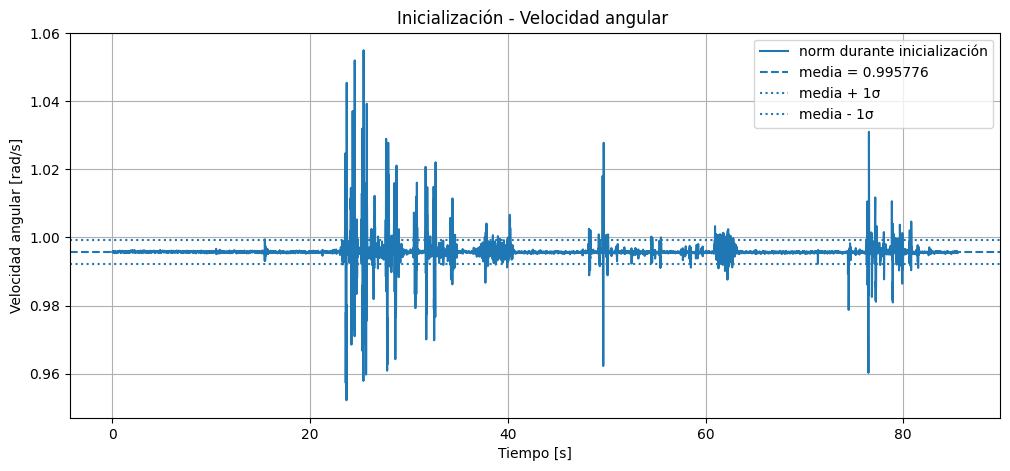

In [30]:
specific_force_with_umbrals()

In [31]:
def specific_force_with_umbrals():

    scaledAccel = df[["scaledGyroX", "scaledGyroY", "scaledGyroZ"]].values

    values_norm = np.linalg.norm(scaledAccel, axis=1)

    axis_mean = np.mean(values_norm)
    axis_var = np.var(values_norm)
    axis_std = np.std(values_norm)
    th_value = axis_mean + 3 * axis_std

    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # Convertir también la columna actual a numérico por seguridad

    plt.figure(figsize=(12, 5))
    plt.plot(t, values_norm, label=f"norm durante inicialización", linewidth=1.5)
    plt.axhline(axis_mean, linestyle="--", label=f"media = {axis_mean:.6f}")
    plt.axhline(axis_mean + axis_std, linestyle=":", label=f"media + 1σ ")
    plt.axhline(axis_mean - axis_std, linestyle=":", label=f"media - 1σ ")

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad angular [rad/s]")
    plt.title(f"Inicialización - Velocidad angular ")
    plt.legend()
    plt.grid(True)
    plt.show()

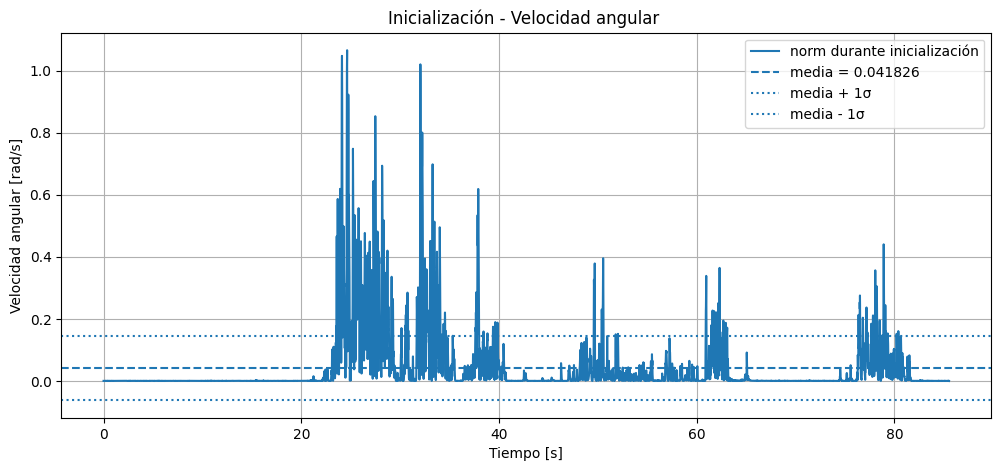

In [32]:
specific_force_with_umbrals()

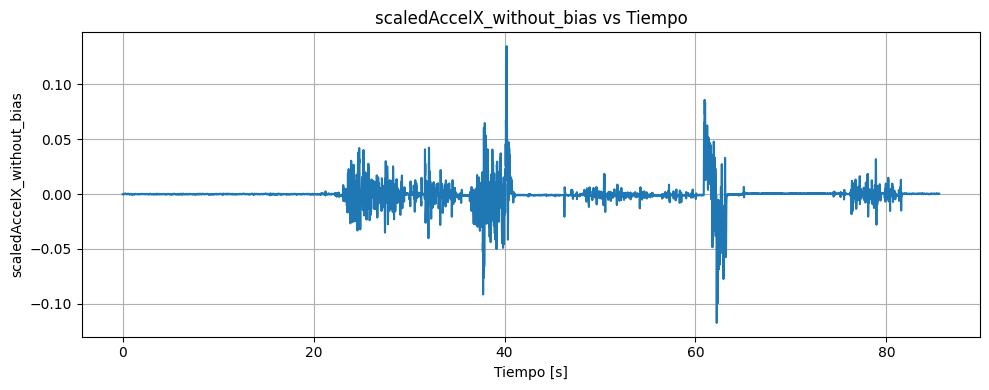

scaledAccelX_without_bias  u: 0.007668312901417525  o2: 2.7322430695744796e-05  o: 0.0052270862529467405


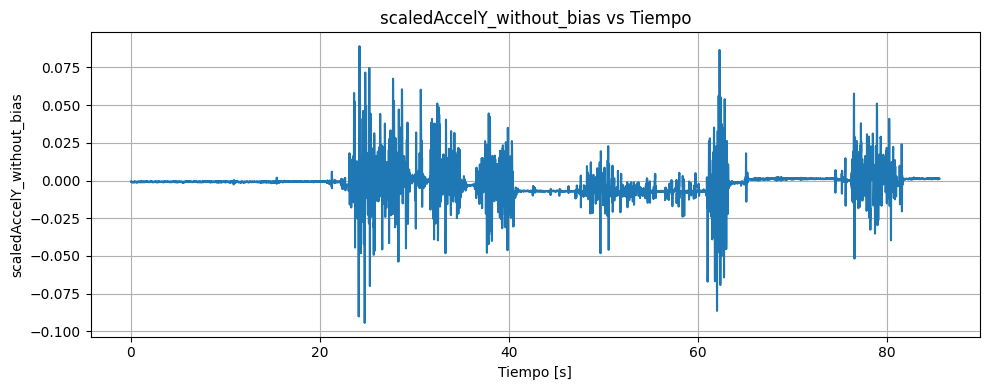

scaledAccelY_without_bias  u: 0.002407944577096069  o2: 0.00011868106709172651  o: 0.010894084040970425


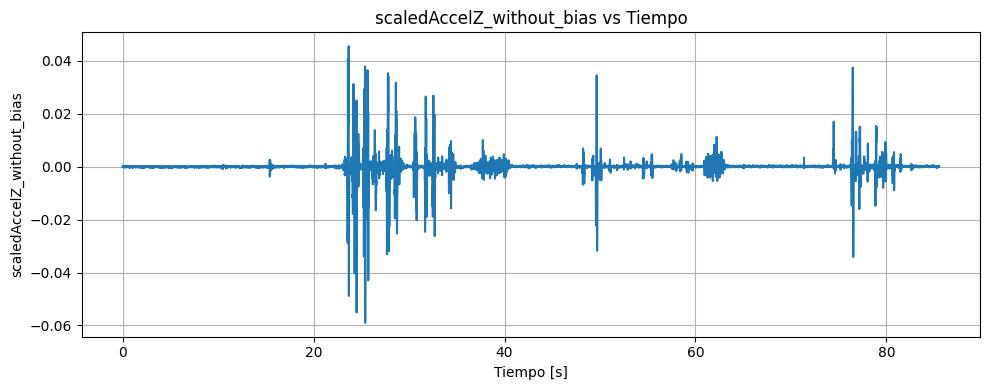

scaledAccelZ_without_bias  u: -0.9957125638922055  o2: 2.3216492277995558e-05  o: 0.004818349538793918


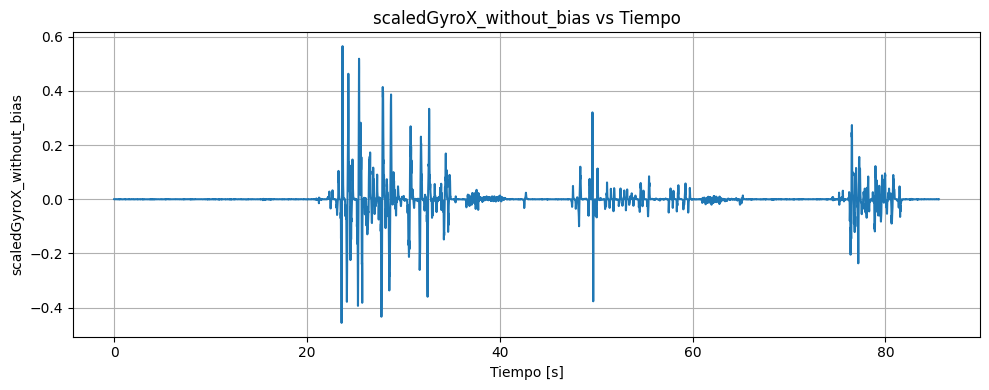

scaledGyroX_without_bias  u: 3.2491784350433606e-05  o2: 0.0037339354451462275  o: 0.06110593625128599


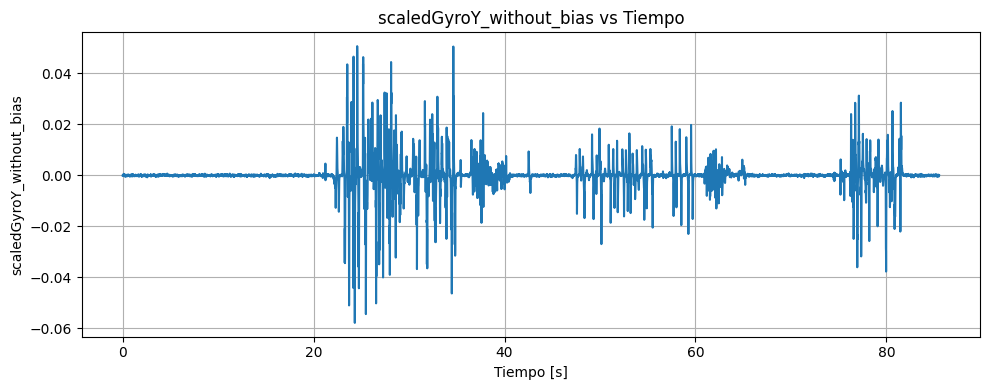

scaledGyroY_without_bias  u: -7.063920666627957e-05  o2: 4.226292438686661e-05  o: 0.0065009941075859015


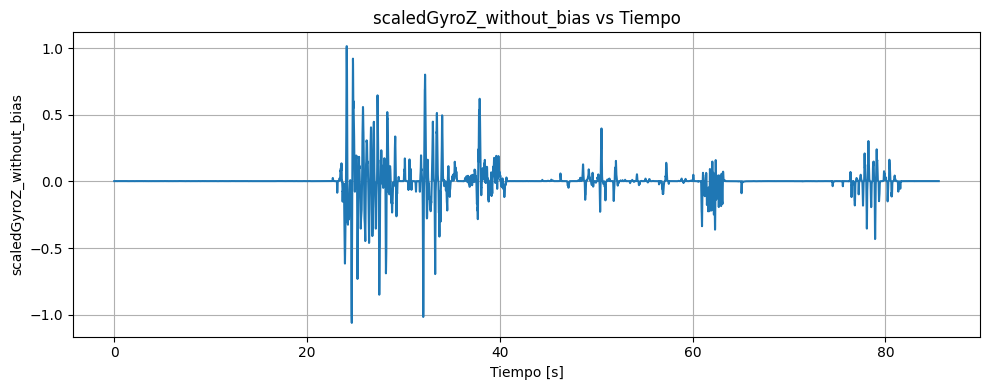

scaledGyroZ_without_bias  u: -0.0022932082299707214  o2: 0.017432031951774823  o: 0.13203042055441172


In [33]:
def data_without_bias(df, col_input, col_output):

    # df[col_output] = df[col_input] - mean(df, col_input)
    df[col_output] = df[col_input] - biases[col_input]

    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col_output], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_output)
    plt.title(f"{col_output} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df.columns[1:7]:
    data_without_bias(df=df, col_input=column, col_output=column+"_without_bias")
    print(column+"_without_bias", " u:", biases[column], " o2:", var[column]," o:", std[column])

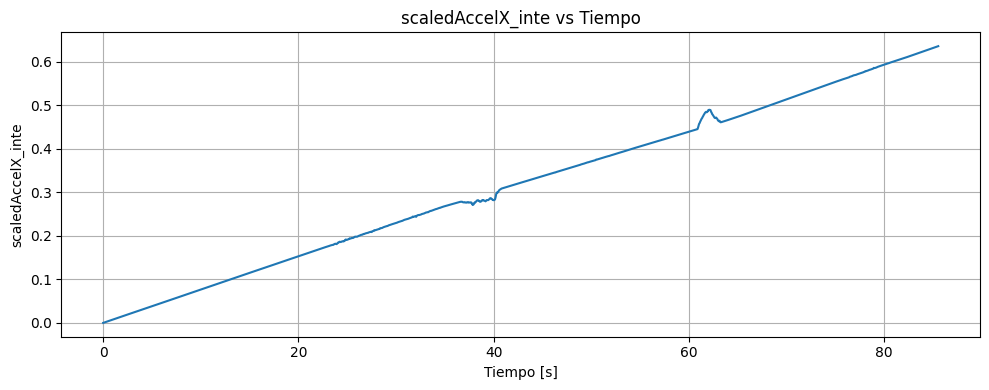

scaledAccelX_inte  u: 0.007439115671773871  o2: 0.00010102175799526937  o: 0.010050958063551423


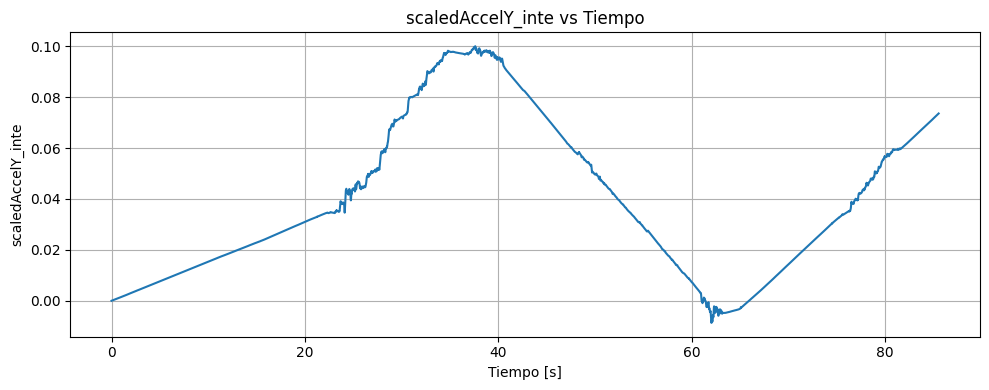

scaledAccelY_inte  u: 0.000860236848353127  o2: 0.00011092442201041907  o: 0.010532066369446171


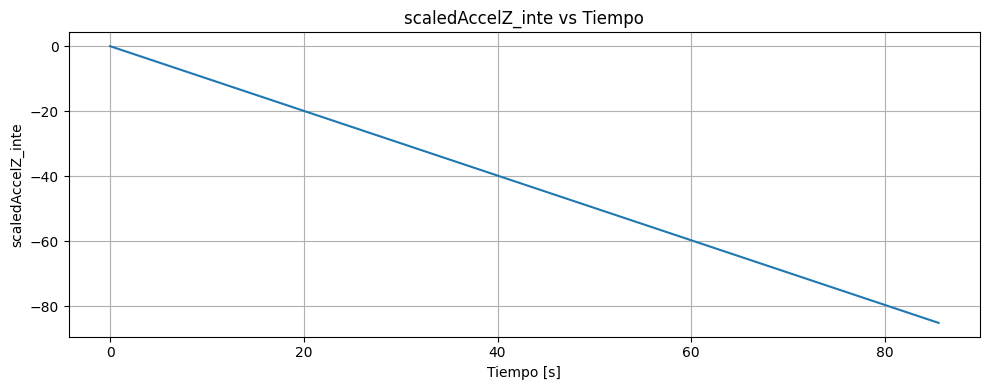

scaledAccelZ_inte  u: -0.9956417328806327  o2: 1.246592380188406e-05  o: 0.00353071151496183


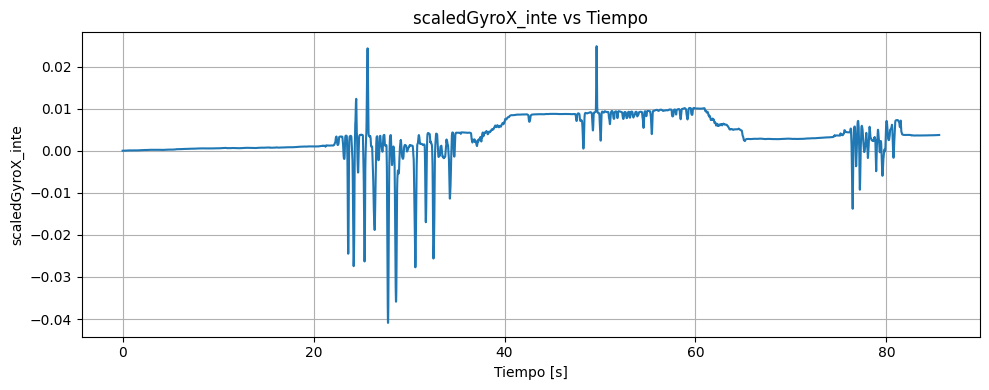

scaledGyroX_inte  u: 4.3781964534203605e-05  o2: 0.002031034706348217  o: 0.045067002411389834


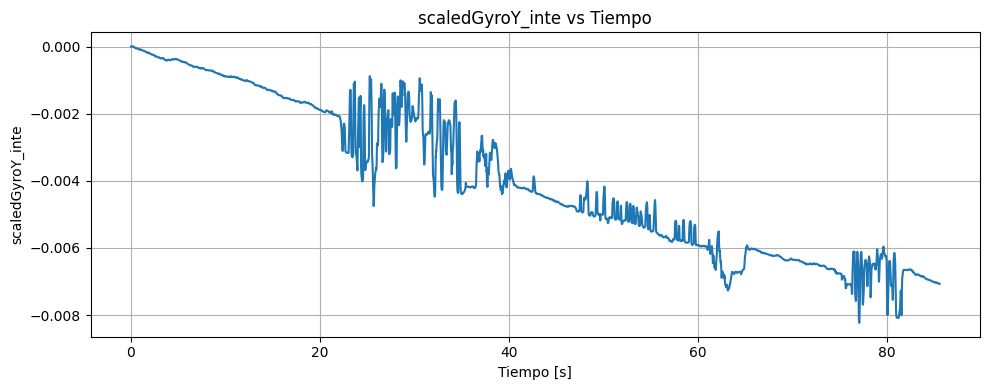

scaledGyroY_inte  u: -8.26865266571699e-05  o2: 2.953415158565337e-05  o: 0.005434533244507146


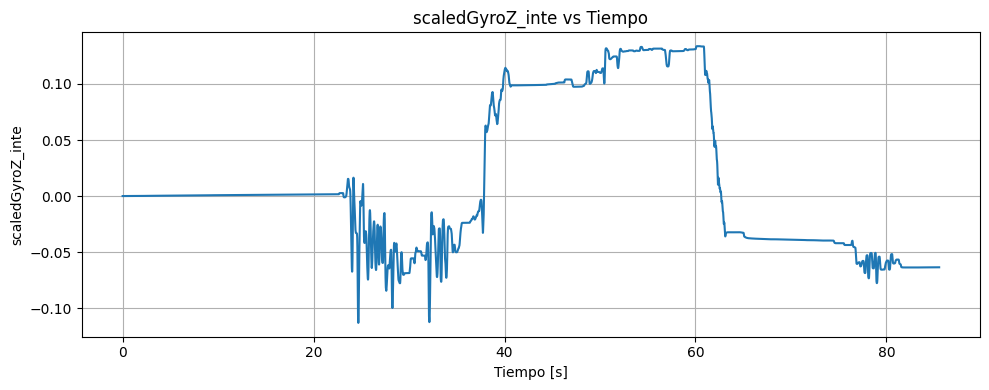

scaledGyroZ_inte  u: -0.0007429326407944792  o2: 0.010452865219616534  o: 0.10223925478805357


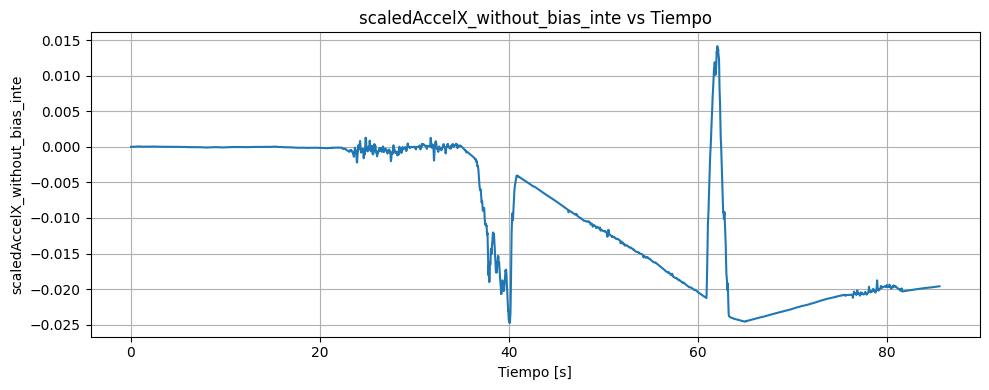

scaledAccelX_without_bias_inte  u: -0.00022919722964365386  o2: 0.00010102175799526937  o: 0.010050958063551423


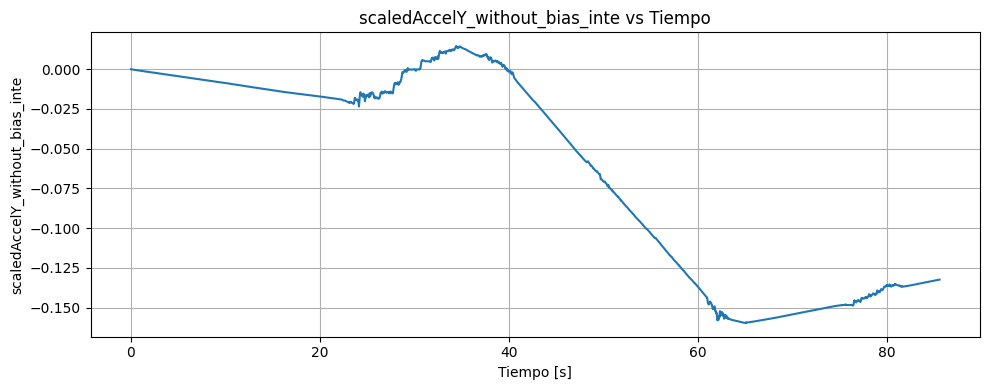

scaledAccelY_without_bias_inte  u: -0.0015477077287429418  o2: 0.00011092442201041907  o: 0.010532066369446171


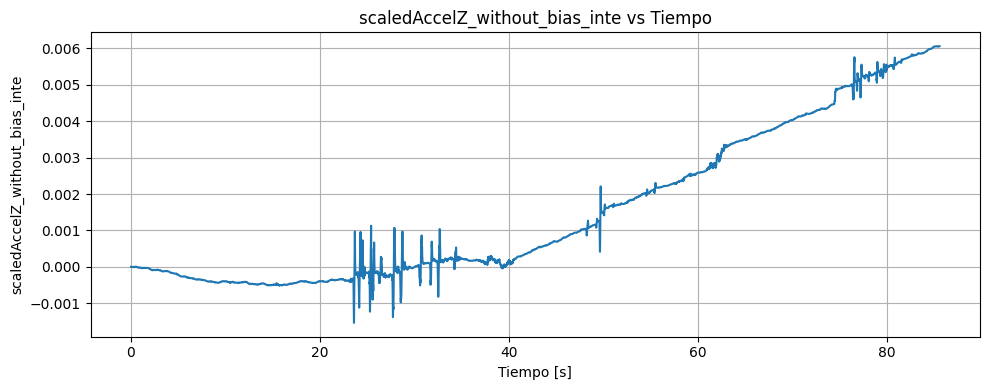

scaledAccelZ_without_bias_inte  u: 7.083101157282233e-05  o2: 1.2465923801884058e-05  o: 0.0035307115149618294


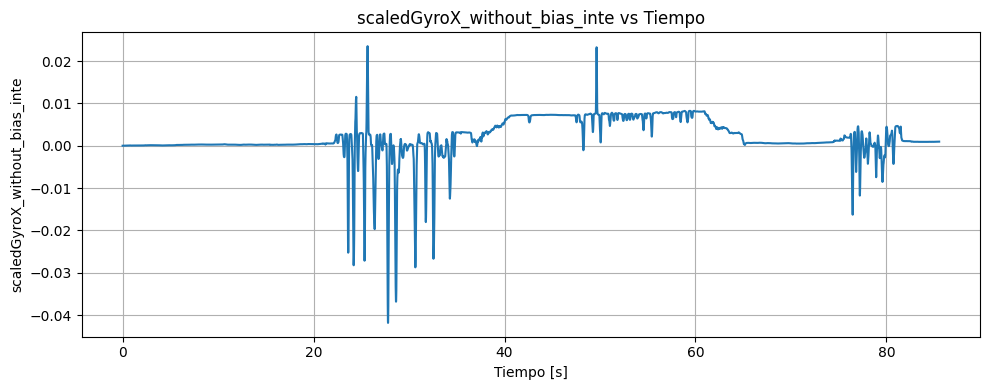

scaledGyroX_without_bias_inte  u: 1.1290180183769865e-05  o2: 0.002031034706348217  o: 0.045067002411389834


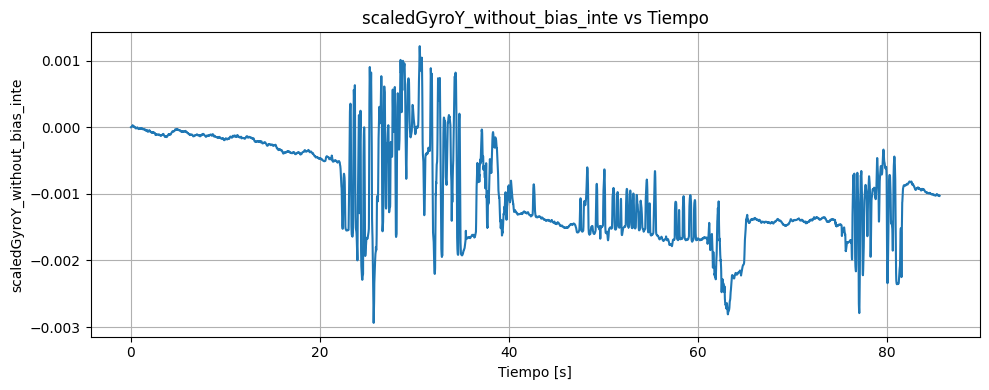

scaledGyroY_without_bias_inte  u: -1.2047319990890339e-05  o2: 2.9534151585653364e-05  o: 0.0054345332445071455


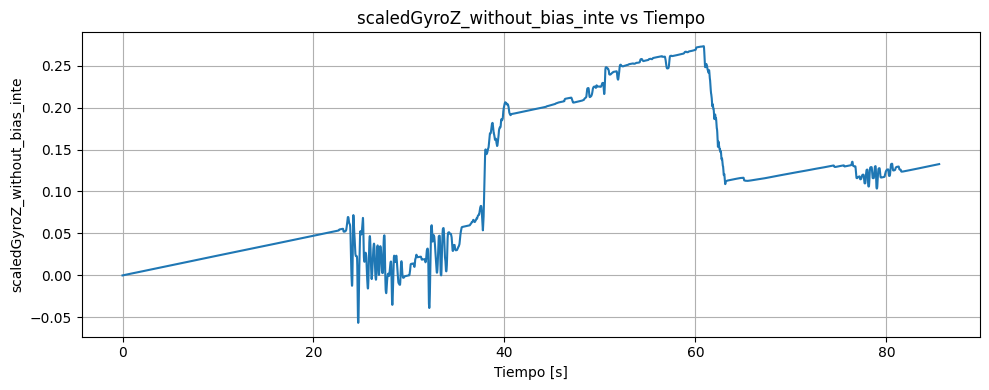

scaledGyroZ_without_bias_inte  u: 0.0015502755891762417  o2: 0.010452865219616534  o: 0.10223925478805357
Index(['Time', 'scaledAccelX', 'scaledAccelY', 'scaledAccelZ', 'scaledGyroX',
       'scaledGyroY', 'scaledGyroZ', 'scaledAccelX_without_bias',
       'scaledAccelY_without_bias', 'scaledAccelZ_without_bias',
       'scaledGyroX_without_bias', 'scaledGyroY_without_bias',
       'scaledGyroZ_without_bias'],
      dtype='str')


In [34]:
def plot_integ_data_vs_time(df, col_input):#, col_output):
    # df = df.copy()

    y = np.cumsum(df[col_input]) * dt

    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # y = df[col_output]

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_input+'_inte')
    plt.title(f"{col_input+'_inte'} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df.columns[1:]:
    plot_integ_data_vs_time(df=df, col_input=column)#col_output=column+"_inte")
    # print(column+"_inte", " u:", mean(df,column+"_inte"), " o2:", variance(df,column+"_inte")," o:", standard_deviation(df,column+"_inte"))
    print(column+"_inte", " u:", mean(df, column), " o2:", variance(df, column)," o:", standard_deviation(df, column))

print(df.columns[:])
# for column in df.columns[1:]:
#     print(column, " u:", mean(df,column), " o2:", variance(df,column)," o:", standard_deviation(df,column))
    

In [35]:
sigma_randow_walk = {}

tiempo_total = len(df) * dt
# print(T)

# print(list(biases))
# print(list(var))

def sigma_rw():
    for keys in list(std):
        # print(keys)
        sigma_randow_walk[keys] = std[keys] * np.sqrt(dt * tiempo_total)

sigma_rw()

print(std)
print(sigma_randow_walk)
        
print(std['scaledAccelX'])

{'scaledAccelX': np.float64(0.0052270862529467405), 'scaledAccelY': np.float64(0.010894084040970425), 'scaledAccelZ': np.float64(0.004818349538793918), 'scaledGyroX': np.float64(0.06110593625128599), 'scaledGyroY': np.float64(0.0065009941075859015), 'scaledGyroZ': np.float64(0.13203042055441172)}
{'scaledAccelX': np.float64(0.004834419015470225), 'scaledAccelY': np.float64(0.010075702694614549), 'scaledAccelZ': np.float64(0.0044563872693693714), 'scaledGyroX': np.float64(0.05651555874074044), 'scaledGyroY': np.float64(0.006012628836085403), 'scaledGyroZ': np.float64(0.12211208020318132)}
0.0052270862529467405


0.004834419015470225


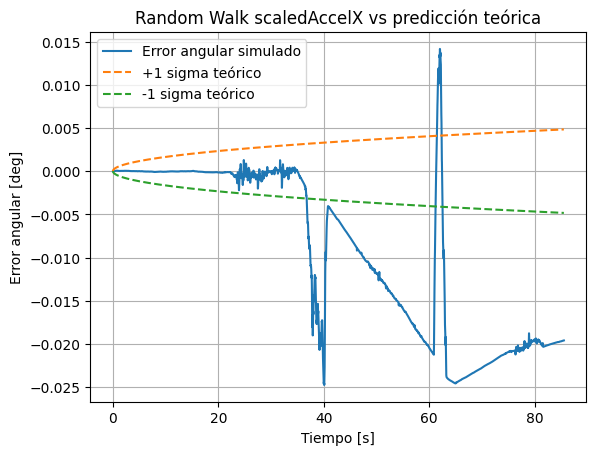

0.010075702694614549


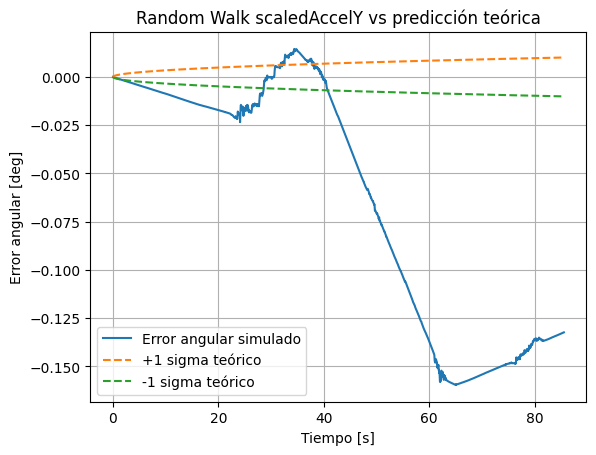

0.0044563872693693714


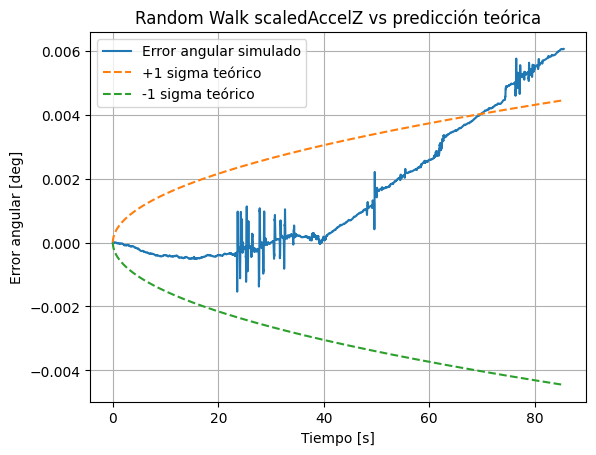

0.05651555874074044


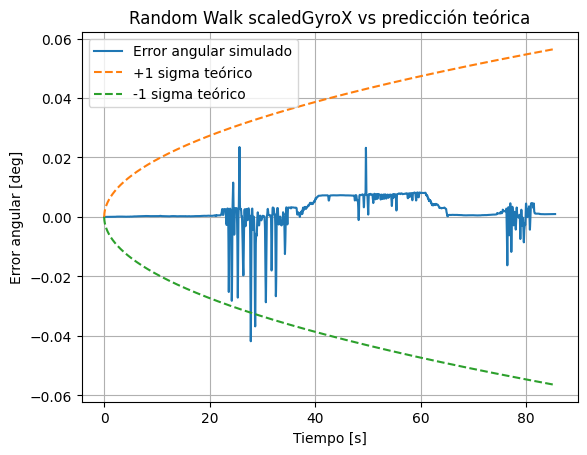

0.006012628836085403


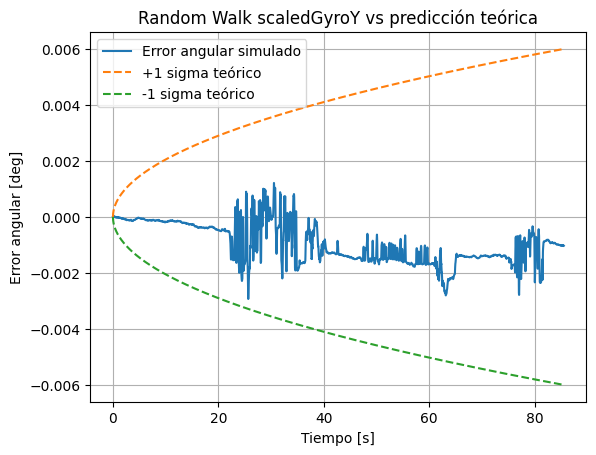

0.12211208020318132


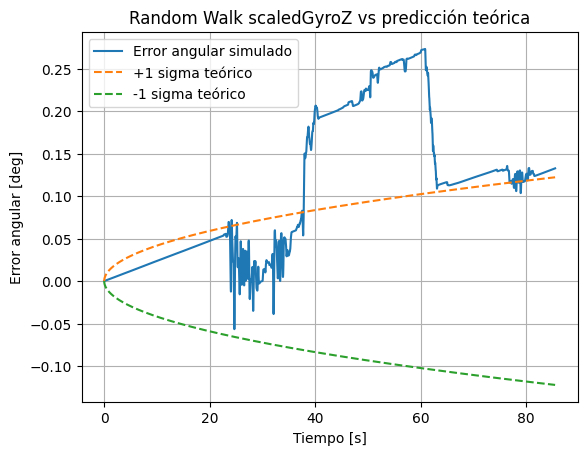

In [36]:
def plot_angular_error_prediction(df, col):
    
    theta = np.cumsum(df[col]) * dt

    t = (df["Time"] - df["Time"].iloc[0]) / 1e9
    # print(t)
    
    name_column_clear = col.rsplit('_without_bias')[0]

    print(sigma_randow_walk[name_column_clear])

    sigma_theta_teorico = std[name_column_clear] * np.sqrt(dt * t)

    plt.plot(t, theta, label="Error angular simulado")
    plt.plot(t, sigma_theta_teorico, "--", label="+1 sigma teórico")
    plt.plot(t, -sigma_theta_teorico, "--", label="-1 sigma teórico")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Error angular [deg]")
    plt.title(f"Random Walk {name_column_clear} vs predicción teórica")
    plt.legend()
    plt.grid()
    plt.show()

for column in df.columns[7:13]:
    # print(column)
    # name_clear = column.rsplit('_without_bias')[0]

    # print(name_clear)
    plot_angular_error_prediction(df=df, col=column)